## Image Cleaning - Open CV for MNIST

The objective of this Python notebook is to compare 5 different Image Cleaning techniques on the Keras MNIST dataset, via OpenCV.

The methods used here are:
- No Processing
- MinMax Scaling
- StandardScaler
- QuantileTransformer
- PCA

In [1]:
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

from keras.datasets import mnist

In [2]:
(trainImg, trainLabel), (testImg, testLabel) = mnist.load_data()

print(trainLabel.shape, testLabel.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000,) (10000,)


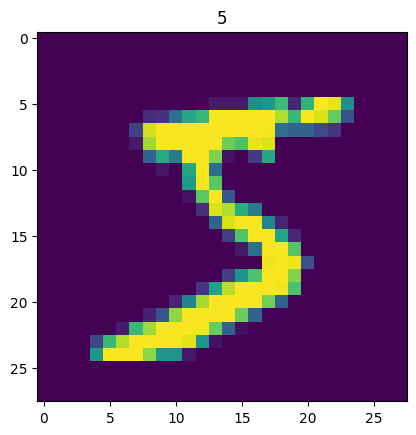

In [3]:
image = trainImg[0]
label = trainLabel[0]

plt.imshow(image)
plt.title(label)
plt.show()

## Image Cleaning Methods

In [4]:
# Method 1 - No Cleaning

def noClean(img):
  return img

In [5]:
# Method 2 - MinMaxScaling

def minMaxScaling(img):
  img = img.astype(np.float32)
  featureRange = (0, 1)
  return cv2.normalize(img, None, alpha=featureRange[0], beta=featureRange[1], norm_type=cv2.NORM_MINMAX)

In [6]:
# Method 3 - Standard Scaling

def standardScaling(img):
  imgTemp = img.astype(np.float32)
  mean = np.mean(imgTemp)
  std = np.std(imgTemp)

  return (imgTemp - mean) / std

In [14]:
# Method 4 - QuantileTransformer

def quantileTransforming(img):
  imgTemp = img.astype(np.float32)
  imgFlat = imgTemp.flatten()
  sortedImg = np.sort(imgFlat)

  cdf = np.linspace(0, 1, len(sortedImg))

  transformedValues = np.interp(imgFlat, sortedImg, cdf)

  return transformedValues.reshape(image.shape)

In [15]:
# Method 5 - PCA

def pcaMethod(img):
  imgTemp = img.astype(np.float32)
  flatImg = imgTemp.reshape(-1, image.shape[-1])

  mean = np.mean(flatImg, axis=0)
  centeredData = flatImg - mean

  covarianceMatrix = np.cov(centeredData, rowvar=False)
  eigenValues, eigenVectors = np.linalg.eigh(covarianceMatrix)

  sortedIndices = np.argsort(eigenValues)[::-1]
  eigenVectorsSorted = eigenVectors[:, sortedIndices]

  eigenVectorsFinal = eigenVectorsSorted[:, :50]

  pcaProjection = np.dot(centeredData, eigenVectorsFinal)

  reconstructedData = np.dot(pcaProjection, eigenVectorsFinal.T) + mean
  return reconstructedData.reshape(image.shape)

## Simple RNN Model

In [16]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

def initRNN():
    model = Sequential([SimpleRNN(128, input_shape=(28, 28)), Dense(10, activation="softmax")])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [17]:
# Need to make labels Categorical for RNN
from keras.utils import to_categorical

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [18]:
def comparisonModels(cleaningMethod):
  # Apply cleaning method to each image in train/test set
  trainImg2 = np.array([cleaningMethod(img) for img in trainImg])
  testImg2 = np.array([cleaningMethod(img) for img in testImg])

  # Normalising and re-shaping the images
  trainImg2 = (trainImg2/255.0).reshape(-1, 28, 28)
  testImg2 = (testImg2/255.0).reshape(-1, 28, 28)

  # RNN Model
  model = initRNN()
  model.fit(trainImg2, trainLabelCategorical, epochs=5, batch_size=64)

  return model.evaluate(testImg2, testLabelCategorical)

## Evaluation

In [19]:
modelNoCleaning = comparisonModels(noClean)
modelMinMax = comparisonModels(minMaxScaling)
modelStandard = comparisonModels(standardScaling)
modelQuantile = comparisonModels(quantileTransforming)
modelPCA = comparisonModels(pcaMethod)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.7998 - loss: 0.6433
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9395 - loss: 0.2077
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9543 - loss: 0.1589
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9602 - loss: 0.1373
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9632 - loss: 0.1226
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9590 - loss: 0.1342
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.4886 - loss: 1.4818
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7823 - loss: 0.6998
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8418 - loss: 0.5036
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8689 - loss: 0.4230
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8831 - loss: 0.3794
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.

In [20]:
listAllModels = [modelNoCleaning, modelMinMax, modelStandard, modelQuantile, modelPCA]
print(listAllModels)

[[0.12300131469964981, 0.9641000032424927], [0.35258278250694275, 0.8820000290870667], [0.2554759085178375, 0.920799970626831], [1.968488097190857, 0.25040000677108765], [0.12026209384202957, 0.9671000242233276]]


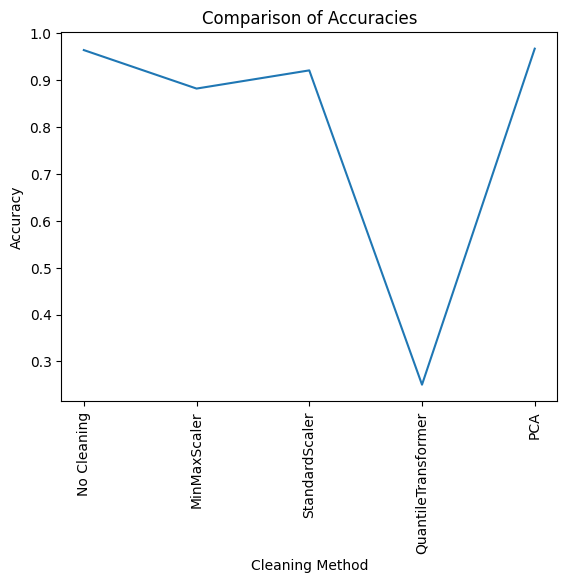

<Figure size 1200x1000 with 0 Axes>

In [21]:
plt.plot(["No Cleaning", "MinMaxScaler", "StandardScaler", "QuantileTransformer", "PCA"], [val[1] for val in listAllModels])
plt.title("Comparison of Accuracies")
plt.xlabel("Cleaning Method")
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.figure(figsize=(12, 10))
plt.show()

In the above graph:
- PCA is the best performer in this case.
- Quantile Transform is by far the worst performer.
- No cleaning continued to give a pretty good accuracy for MNIST.
- MinMax and Standard Scaling perform decently.